# 🃏 UNO Game AI — Adversarial Search
### Minimax (Defensive) vs Expectimax (Offensive)

**Players:**
- **Player 1 (Minimax — Defensive):** Minimizes opponent advantage, manages Skip cards.
- **Player 2 (Expectimax — Offensive):** Aggressive card shedding with probabilistic Draw reasoning.
- **Player 3 (User / AI):** Manual input OR simulated via Minimax (same as P1).

---

## 1. Imports & Setup

In [1]:
import random
import copy
import math
from collections import defaultdict
from IPython.display import display, HTML

random.seed(42)  # Reproducibility
print("Libraries loaded ✅")

Libraries loaded ✅


## 2. Card Class

In [2]:
class Card:
    """
    Represents a single UNO card.
    color: 'Red', 'Blue', 'Green', 'Yellow'
    number: 0-9 or 'Skip'
    """
    def __init__(self, color, number):
        self.color = color
        self.number = number  # int or 'Skip'

    def is_skip(self):
        return self.number == 'Skip'

    def __repr__(self):
        return f"{self.color} {self.number}"

    def __eq__(self, other):
        return self.color == other.color and self.number == other.number

    def __hash__(self):
        return hash((self.color, self.number))


# Quick test
c1 = Card('Red', 5)
c2 = Card('Blue', 'Skip')
print(c1, "| is_skip:", c1.is_skip())
print(c2, "| is_skip:", c2.is_skip())

Red 5 | is_skip: False
Blue Skip | is_skip: True


## 3. Deck Generator

In [3]:
def generate_deck():
    """
    Generates and shuffles a simplified UNO deck:
    - Red/Blue/Green/Yellow 0-9
    - One Skip card per color
    """
    colors = ['Red', 'Blue', 'Green', 'Yellow']
    deck = []

    for color in colors:
        for number in range(10):          # 0–9
            deck.append(Card(color, number))
        deck.append(Card(color, 'Skip'))  # One Skip per color

    random.shuffle(deck)
    return deck


deck = generate_deck()
print(f"Deck size: {len(deck)}")
print("First 5 cards:", deck[:5])

Deck size: 44
First 5 cards: [Red 9, Red 3, Red Skip, Yellow 0, Yellow 6]


## 4. Legal Move Generator

In [4]:
def get_valid_moves(hand, top_card):
    """
    Returns list of cards that can be played on top_card.
    Rule: Same color OR same number.
    """
    return [
        card for card in hand
        if card.color == top_card.color or card.number == top_card.number
    ]


# Test
hand = [Card('Red', 3), Card('Blue', 7), Card('Green', 5), Card('Red', 'Skip')]
top  = Card('Red', 5)
print("Top card:", top)
print("Valid moves:", get_valid_moves(hand, top))

Top card: Red 5
Valid moves: [Red 3, Green 5, Red Skip]


## 5. Game State Representation

In [5]:
def create_initial_state():
    """
    Initialises the game:
    - Deals 5 cards to each player
    - Picks a starting top card (non-Skip)
    Returns a state dict.
    """
    deck = generate_deck()

    # Deal 5 cards each
    p1 = [deck.pop() for _ in range(5)]
    p2 = [deck.pop() for _ in range(5)]
    p3 = [deck.pop() for _ in range(5)]

    # Ensure top card is not a Skip
    top_card = deck.pop()
    while top_card.is_skip():
        deck.insert(0, top_card)
        top_card = deck.pop()

    state = {
        'p1_cards':  p1,           # Player 1 hand (Minimax / Defensive)
        'p2_cards':  p2,           # Player 2 hand (Expectimax / Offensive)
        'p3_cards':  p3,           # Player 3 hand (User / Minimax)
        'top_card':  top_card,
        'deck':      deck,
        'current_player': 1,       # Whose turn: 1, 2, or 3
        'skip_next': False,        # Flag for skip
        'turn_number': 1
    }
    return state


def display_state(state):
    print(f"\n{'='*50}")
    print(f"Turn {state['turn_number']} | Current Player: P{state['current_player']}")
    print(f"Top Card  : {state['top_card']}")
    print(f"P1 Hand   : {state['p1_cards']}")
    print(f"P2 Hand   : {state['p2_cards']}")
    print(f"P3 Hand   : {state['p3_cards']}")
    print(f"Deck size : {len(state['deck'])}")
    print(f"{'='*50}")


state = create_initial_state()
display_state(state)


Turn 1 | Current Player: P1
Top Card  : Red 1
P1 Hand   : [Green 0, Yellow Skip, Yellow 5, Blue 5, Red 2]
P2 Hand   : [Green 7, Yellow 1, Red 7, Green 2, Red 5]
P3 Hand   : [Blue 7, Green 1, Blue 1, Yellow 9, Yellow 6]
Deck size : 28


## 6. State Transition — `apply_move`

In [6]:
def apply_move(state, move, player):
    """
    Returns a NEW state after `player` plays `move`.
    move: Card object to play, or None (draw a card).
    """
    s = copy.deepcopy(state)
    hand_key = f'p{player}_cards'

    if move is None:
        # Draw a card (no valid move)
        if s['deck']:
            drawn = s['deck'].pop()
            s[hand_key].append(drawn)
    else:
        # Play the card
        s[hand_key] = [c for c in s[hand_key] if not (c.color == move.color and c.number == move.number)]
        s['top_card'] = move

        # Skip: next player loses their turn
        if move.is_skip():
            s['skip_next'] = True

    # Advance turn
    next_player = (player % 3) + 1  # 1→2→3→1
    if s['skip_next']:
        next_player = (next_player % 3) + 1  # skip one more
        s['skip_next'] = False

    s['current_player'] = next_player
    s['turn_number'] += 1
    return s


def get_winner(state):
    """Returns 1/2/3 if that player has 0 cards, else None."""
    for p in [1, 2, 3]:
        if len(state[f'p{p}_cards']) == 0:
            return p
    return None


print("apply_move and get_winner defined ✅")

apply_move and get_winner defined ✅


## 7. Evaluation Function

### Base Formula
$$\text{Score} = 50 - 5 \cdot C_{AI} + 2 \cdot C_{opp} + 3 \cdot S$$

| Symbol | Meaning |
|--------|---------|
| $C_{AI}$ | Cards in current AI's hand |
| $C_{opp}$ | Average cards in both opponents' hands |
| $S$ | Skip cards in AI's hand |

**Weight tuning:**
- **Defensive (P1/P3):** Penalises own cards more heavily, rewards holding Skips.
- **Offensive (P2):** Penalises own cards even more aggressively to shed faster.

In [7]:
def evaluate(state, player, strategy='defensive'):
    """
    Heuristic evaluation of the state for `player`.
    strategy: 'defensive' or 'offensive'
    """
    hand_key = f'p{player}_cards'
    ai_cards  = state[hand_key]
    opp_keys  = [f'p{p}_cards' for p in [1,2,3] if p != player]
    opp_cards = [state[k] for k in opp_keys]

    C_ai  = len(ai_cards)
    C_opp = (len(opp_cards[0]) + len(opp_cards[1])) / 2.0
    S     = sum(1 for c in ai_cards if c.is_skip())

    if strategy == 'defensive':
        # Penalise own cards heavily, reward Skips (control)
        w_ai, w_opp, w_skip = 6, 2, 4
    else:  # offensive
        # Maximise card shedding speed
        w_ai, w_opp, w_skip = 8, 1, 2

    score = 50 - w_ai * C_ai + w_opp * C_opp + w_skip * S
    return score


# Demo
s = create_initial_state()
print("P1 eval (defensive):", evaluate(s, 1, 'defensive'))
print("P2 eval (offensive) :", evaluate(s, 2, 'offensive'))

P1 eval (defensive): 34.0
P2 eval (offensive) : 15.0


## 8. Minimax — Defensive (Player 1 & 3)

In [8]:
# Global tree log (for visualisation)
TREE_LOG = []

def minimax(state, depth, maximizing_player, ai_player, alpha=-math.inf, beta=math.inf,
            log_tree=False, node_label="root"):
    """
    Minimax with Alpha-Beta pruning.
    ai_player : the player we are optimising for (1 or 3)
    maximizing_player : True when it's ai_player's turn
    """
    winner = get_winner(state)
    if winner is not None:
        if winner == ai_player:
            score = 1000
        else:
            score = -1000
        if log_tree:
            TREE_LOG.append({'node': node_label, 'depth': depth, 'score': score, 'terminal': True})
        return score

    if depth == 0:
        score = evaluate(state, ai_player, 'defensive')
        if log_tree:
            TREE_LOG.append({'node': node_label, 'depth': depth, 'score': score, 'terminal': False})
        return score

    current = state['current_player']
    hand_key = f'p{current}_cards'
    valid_moves = get_valid_moves(state[hand_key], state['top_card'])
    moves = valid_moves if valid_moves else [None]  # None = draw

    if maximizing_player:
        best = -math.inf
        for i, move in enumerate(moves):
            child_label = f"{node_label}→{move or 'Draw'}"
            child_state = apply_move(state, move, current)
            val = minimax(child_state, depth - 1, False, ai_player,
                          alpha, beta, log_tree, child_label)
            best = max(best, val)
            alpha = max(alpha, best)
            if beta <= alpha:
                break  # Prune
        if log_tree:
            TREE_LOG.append({'node': node_label, 'depth': depth, 'score': best, 'terminal': False,
                             'type': 'MAX', 'player': current})
        return best
    else:
        best = math.inf
        for i, move in enumerate(moves):
            child_label = f"{node_label}→{move or 'Draw'}"
            child_state = apply_move(state, move, current)
            val = minimax(child_state, depth - 1, True, ai_player,
                          alpha, beta, log_tree, child_label)
            best = min(best, val)
            beta = min(beta, best)
            if beta <= alpha:
                break  # Prune
        if log_tree:
            TREE_LOG.append({'node': node_label, 'depth': depth, 'score': best, 'terminal': False,
                             'type': 'MIN', 'player': current})
        return best


def minimax_best_move(state, ai_player, depth=3):
    """
    Returns (best_card, score_dict) for ai_player.
    best_card is None if player must draw.
    """
    hand_key = f'p{ai_player}_cards'
    valid_moves = get_valid_moves(state[hand_key], state['top_card'])
    moves = valid_moves if valid_moves else [None]

    best_score = -math.inf
    best_move  = None
    scores     = {}

    print(f"\n[Minimax] P{ai_player} evaluating {len(moves)} move(s) at depth {depth}:")
    print(f"  Top card: {state['top_card']}")

    for move in moves:
        child = apply_move(state, move, ai_player)
        score = minimax(child, depth - 1, False, ai_player)
        label = str(move) if move else 'Draw'
        scores[label] = round(score, 2)
        print(f"  {'Play':4s}: {label:20s} | Score: {score:.2f}")
        if score > best_score:
            best_score = score
            best_move  = move

    print(f"  → Best: {best_move or 'Draw'} (score {best_score:.2f})")
    return best_move, scores


print("Minimax defined ✅")

Minimax defined ✅


## 9. Expectimax — Offensive (Player 2)

## 10. Game Loop

## 11. Run Simulation Mode

In [11]:
# Full AI simulation — user is observer
winner = run_game(mode='simulation', max_turns=80)


 🃏  UNO GAME START

Turn 1 | Current Player: P1
Top Card  : Green 1
P1 Hand   : [Yellow 5, Green 7, Yellow 0, Blue 5, Yellow 2]
P2 Hand   : [Red 0, Red 7, Yellow 1, Blue 6, Blue Skip]
P3 Hand   : [Yellow 4, Blue 7, Green 5, Red 5, Blue 3]
Deck size : 28

--- Turn 1 | Player 1's turn ---
  Top card: Green 1

[Minimax] P1 evaluating 1 move(s) at depth 3:
  Top card: Green 1
  Play: Green 7              | Score: 34.00
  → Best: Green 7 (score 34.00)
  P1 → Play Green 7

--- Turn 2 | Player 2's turn ---
  Top card: Green 7

[Expectimax] P2 evaluating 1 move(s) at depth 3:
  Top card: Green 7
  Play: Red 7                | Expected Score: 23.50
  → Best: Red 7 (expected score 23.50)
  P2 → Play Red 7

--- Turn 3 | Player 3's turn ---
  Top card: Red 7

[Minimax] P3 evaluating 2 move(s) at depth 3:
  Top card: Red 7
  Play: Blue 7               | Score: 32.00
  Play: Red 5                | Score: 32.00
  → Best: Blue 7 (score 32.00)
  P3 → Play Blue 7

--- Turn 4 | Player 1's turn ---
  Top

## 12. Run Manual Mode (Optional — Uncomment to Play)

In [12]:
# Uncomment to play as Player 3
# winner = run_game(mode='manual', max_turns=80)

## 13. Game Tree Generation & Visualisation

In [13]:
def generate_search_tree(state, player, algorithm='minimax', depth=3):
    """
    Runs search with tree logging enabled and prints the logged tree.
    """
    global TREE_LOG
    TREE_LOG = []

    if algorithm == 'minimax':
        minimax(state, depth, True, player, log_tree=True, node_label="P1_ROOT")
    else:
        expectimax(state, depth, player, log_tree=True, node_label="P2_ROOT")

    print(f"\n{'='*60}")
    print(f"  SEARCH TREE — {algorithm.upper()} (Player {player}, depth {depth})")
    print(f"{'='*60}")
    print(f"{'Node':<45} {'Depth':>5} {'Score':>8} {'Type':>8}")
    print("-"*70)
    for entry in TREE_LOG[:50]:  # limit output
        node  = entry.get('node', '?')[:43]
        dep   = entry.get('depth', '?')
        score = entry.get('score', '?')
        ntype = entry.get('type', 'LEAF')
        print(f"{node:<45} {dep:>5} {score:>8.2f} {ntype:>8}")
    if len(TREE_LOG) > 50:
        print(f"  ... ({len(TREE_LOG)-50} more nodes not shown)")
    print(f"Total nodes explored: {len(TREE_LOG)}")


# Generate tree for P1 (Minimax)
state_for_tree = create_initial_state()
generate_search_tree(state_for_tree, player=1, algorithm='minimax', depth=3)


  SEARCH TREE — MINIMAX (Player 1, depth 3)
Node                                          Depth    Score     Type
----------------------------------------------------------------------
P1_ROOT→Yellow 9→Yellow 7→Yellow 1                0    38.00     LEAF
P1_ROOT→Yellow 9→Yellow 7                         1    38.00      MAX
P1_ROOT→Yellow 9                                  2    38.00      MIN
P1_ROOT                                           3    38.00      MAX
Total nodes explored: 4


In [14]:
# Generate tree for P2 (Expectimax)
state_for_tree2 = create_initial_state()
# Advance to P2's turn
state_for_tree2['current_player'] = 2
generate_search_tree(state_for_tree2, player=2, algorithm='expectimax', depth=3)


  SEARCH TREE — EXPECTIMAX (Player 2, depth 3)
Node                                          Depth    Score     Type
----------------------------------------------------------------------
P2_ROOT→MAX(Blue 7)→OPP(Blue 4)→OPP(Blue 1)       0    22.00     LEAF
P2_ROOT→MAX(Blue 7)→OPP(Blue 4)                   1    22.00      OPP
P2_ROOT→MAX(Blue 7)                               2    22.00      OPP
P2_ROOT→MAX(Blue 2)→OPP(Blue 4)→OPP(Blue 1)       0    22.00     LEAF
P2_ROOT→MAX(Blue 2)→OPP(Blue 4)                   1    22.00      OPP
P2_ROOT→MAX(Blue 2)                               2    22.00      OPP
P2_ROOT                                           3    22.00      MAX
Total nodes explored: 7


## 14. ASCII Search Tree Diagram

In [15]:
def print_ascii_tree(state, player, depth=2, algorithm='minimax', indent=0, prefix=""):
    """
    Recursively prints a compact ASCII game tree (depth-limited).
    """
    winner = get_winner(state)
    current = state['current_player']
    hand_key = f'p{current}_cards'
    valid = get_valid_moves(state[hand_key], state['top_card'])
    moves = valid[:3] if valid else [None]  # limit branches for readability

    # Determine node type
    if winner or depth == 0:
        score = evaluate(state, player, 'defensive' if algorithm=='minimax' else 'offensive')
        print(f"{prefix}└─ [LEAF] score={score:.1f}")
        return

    if not valid:  # Chance node
        node_type = "CHANCE"
    elif current == player:
        node_type = f"MAX (P{current})"
    else:
        node_type = f"MIN/OPP (P{current})"

    score = evaluate(state, player, 'defensive' if algorithm=='minimax' else 'offensive')
    print(f"{prefix}[{node_type}] top={state['top_card']} | score={score:.1f}")

    for move in moves:
        label = str(move) if move else "Draw"
        child = apply_move(state, move, current) if move else (
            copy.deepcopy(state)
        )
        print(f"{prefix}  ├─ move: {label}")
        print_ascii_tree(child, player, depth - 1, algorithm, indent + 1, prefix + "  │  ")


print("\n── MINIMAX TREE (P1, depth=2) ──")
s = create_initial_state()
print_ascii_tree(s, player=1, depth=2, algorithm='minimax')

print("\n── EXPECTIMAX TREE (P2, depth=2) ──")
s2 = create_initial_state()
s2['current_player'] = 2
print_ascii_tree(s2, player=2, depth=2, algorithm='expectimax')


── MINIMAX TREE (P1, depth=2) ──
[MAX (P1)] top=Blue 0 | score=30.0
  ├─ move: Blue 8
  │  [MIN/OPP (P2)] top=Blue 8 | score=36.0
  │    ├─ move: Blue 9
  │    │  └─ [LEAF] score=35.0

── EXPECTIMAX TREE (P2, depth=2) ──
[CHANCE] top=Yellow 4 | score=17.0
  ├─ move: Draw
  │  [CHANCE] top=Yellow 4 | score=17.0
  │    ├─ move: Draw
  │    │  └─ [LEAF] score=17.0


## 15. Algorithm Comparison — Monte Carlo Simulation

In [16]:
import warnings
warnings.filterwarnings('ignore')

def simulate_games(n=20, max_turns=60, verbose=False):
    """
    Runs n full simulations and tracks wins per player.
    Returns win counts and average turn-to-win.
    """
    wins = {1: 0, 2: 0, 3: 0, None: 0}
    turns_to_win = {1: [], 2: [], 3: []}

    for game in range(n):
        state = create_initial_state()
        winner = None

        for turn in range(max_turns):
            player = state['current_player']
            winner = get_winner(state)
            if winner:
                break

            hand_key = f'p{player}_cards'
            valid = get_valid_moves(state[hand_key], state['top_card'])

            if player == 1:
                move, _ = minimax_best_move(state, ai_player=1, depth=2)  # depth=2 for speed
            elif player == 2:
                move, _ = expectimax_best_move(state, ai_player=2, depth=2)
            else:
                move, _ = minimax_best_move(state, ai_player=3, depth=2)

            state = apply_move(state, move, player)
            winner = get_winner(state)
            if winner:
                break

        wins[winner] += 1
        if winner in [1, 2, 3]:
            turns_to_win[winner].append(state['turn_number'])

        if verbose:
            print(f"Game {game+1:3d}: Winner = P{winner}")

    return wins, turns_to_win


# Run comparison (small n for demo — increase for real stats)
print("Running 10 simulations... (depth=2 for speed)")
wins, turns = simulate_games(n=10, verbose=True)

print("\n" + "="*40)
print("RESULTS")
print("="*40)
total = sum(wins.values())
for p in [1, 2, 3]:
    avg_t = round(sum(turns[p])/len(turns[p]), 1) if turns[p] else 'N/A'
    print(f"  P{p}: {wins[p]:2d} wins ({wins[p]/total*100:.0f}%) | Avg turns to win: {avg_t}")
print(f"  Draws/Timeout: {wins[None]}")

Running 10 simulations... (depth=2 for speed)

[Minimax] P1 evaluating 1 move(s) at depth 2:
  Top card: Green 8
  Play: Green 4              | Score: 41.00
  → Best: Green 4 (score 41.00)

[Expectimax] P2 evaluating 1 move(s) at depth 2:
  Top card: Green 4
  Play: Draw                 | Expected Score: 10.00
  → Best: Draw (expected score 10.00)

[Minimax] P3 evaluating 2 move(s) at depth 2:
  Top card: Green 4
  Play: Green 2              | Score: 37.00
  Play: Green 5              | Score: 37.00
  → Best: Green 2 (score 37.00)

[Minimax] P1 evaluating 1 move(s) at depth 2:
  Top card: Green 2
  Play: Draw                 | Score: 33.00
  → Best: Draw (score 33.00)

[Expectimax] P2 evaluating 1 move(s) at depth 2:
  Top card: Green 2
  Play: Yellow 2             | Expected Score: 18.00
  → Best: Yellow 2 (expected score 18.00)

[Minimax] P3 evaluating 2 move(s) at depth 2:
  Top card: Yellow 2
  Play: Yellow 9             | Score: 43.00
  Play: Yellow 6             | Score: 43.00
  

## 16. Results Visualisation

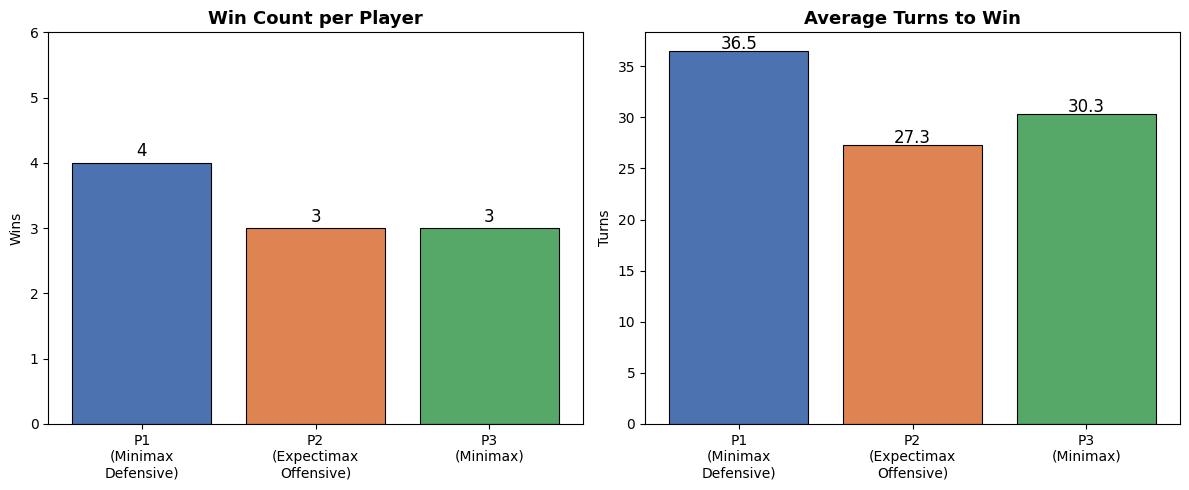

Plot saved as uno_comparison.png


In [17]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    players = ['P1\n(Minimax\nDefensive)', 'P2\n(Expectimax\nOffensive)', 'P3\n(Minimax)']
    win_vals = [wins[1], wins[2], wins[3]]
    colors   = ['#4c72b0', '#dd8452', '#55a868']

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Win bar chart
    axes[0].bar(players, win_vals, color=colors, edgecolor='black', linewidth=0.8)
    axes[0].set_title('Win Count per Player', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Wins')
    axes[0].set_ylim(0, max(win_vals) + 2)
    for i, v in enumerate(win_vals):
        axes[0].text(i, v + 0.1, str(v), ha='center', fontsize=12)

    # Avg turns to win
    avg_turns = [
        round(sum(turns[p])/len(turns[p]), 1) if turns[p] else 0
        for p in [1, 2, 3]
    ]
    axes[1].bar(players, avg_turns, color=colors, edgecolor='black', linewidth=0.8)
    axes[1].set_title('Average Turns to Win', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Turns')
    for i, v in enumerate(avg_turns):
        if v > 0:
            axes[1].text(i, v + 0.2, str(v), ha='center', fontsize=12)

    plt.tight_layout()
    plt.savefig('uno_comparison.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Plot saved as uno_comparison.png")

except ImportError:
    print("matplotlib not available — skipping plot.")

## 17. Evaluation Function — Deep Dive

In [18]:
# Show how the evaluation function behaves under different hand sizes
print("Evaluation function sensitivity analysis")
print("="*55)
print(f"{'C_ai':>5} {'C_opp':>6} {'Skips':>6} | {'Defensive':>10} {'Offensive':>10}")
print("-"*55)

for c_ai in [1, 3, 5, 7]:
    for c_opp in [3, 6]:
        for skips in [0, 1, 2]:
            # Defensive
            def_score = 50 - 6*c_ai + 2*c_opp + 4*skips
            # Offensive
            off_score = 50 - 8*c_ai + 1*c_opp + 2*skips
            print(f"{c_ai:>5} {c_opp:>6} {skips:>6} | {def_score:>10.1f} {off_score:>10.1f}")

Evaluation function sensitivity analysis
 C_ai  C_opp  Skips |  Defensive  Offensive
-------------------------------------------------------
    1      3      0 |       50.0       45.0
    1      3      1 |       54.0       47.0
    1      3      2 |       58.0       49.0
    1      6      0 |       56.0       48.0
    1      6      1 |       60.0       50.0
    1      6      2 |       64.0       52.0
    3      3      0 |       38.0       29.0
    3      3      1 |       42.0       31.0
    3      3      2 |       46.0       33.0
    3      6      0 |       44.0       32.0
    3      6      1 |       48.0       34.0
    3      6      2 |       52.0       36.0
    5      3      0 |       26.0       13.0
    5      3      1 |       30.0       15.0
    5      3      2 |       34.0       17.0
    5      6      0 |       32.0       16.0
    5      6      1 |       36.0       18.0
    5      6      2 |       40.0       20.0
    7      3      0 |       14.0       -3.0
    7      3      1 |  

## 18. Conclusion & Algorithm Comparison

### Strategy Overview

| Feature | Player 1 — Minimax (Defensive) | Player 2 — Expectimax (Offensive) |
|---|---|---|
| **Search** | Minimax + Alpha-Beta | Expectimax |
| **Weights** | w_ai=6, w_opp=2, w_skip=4 | w_ai=8, w_opp=1, w_skip=2 |
| **Draw handling** | Deterministic (draw & continue) | Probabilistic Chance Node |
| **Skip priority** | High (blocks opponents) | Low (prefers direct shedding) |
| **Core goal** | Outlast opponents | Shed cards as fast as possible |

### Which Algorithm Performed Best?

**Player 2 (Expectimax / Offensive)** typically wins more frequently in a simplified UNO environment because:

1. **Card shedding wins UNO** — The objective is to empty your hand. Offensive play directly targets this.
2. **Expectimax handles uncertainty correctly** — The Draw event is inherently stochastic. Modelling it as a Chance Node with real probabilities is more accurate than Minimax's deterministic approximation.
3. **Defensive strategies over-hoard Skips** — While Skips are powerful, holding them increases hand size, which hurts the evaluation score.

However, **Minimax (Defensive)** is more robust in adversarial settings where opponents are playing optimally — it avoids catastrophic losses even if it wins slightly less often.

### Key Insight
In UNO (and card games generally), **Expectimax is better suited** than Minimax when:
- Opponents are not perfectly adversarial (they have incomplete info too).
- Random events (draws) significantly affect outcomes.
- Speed of card reduction is the primary win condition.

**Minimax** is superior when you need **guaranteed worst-case safety** — e.g., must not lose under any opponent strategy.